In [1]:
!pip install -q diffusers transformers accelerate safetensors


In [2]:
import torch
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

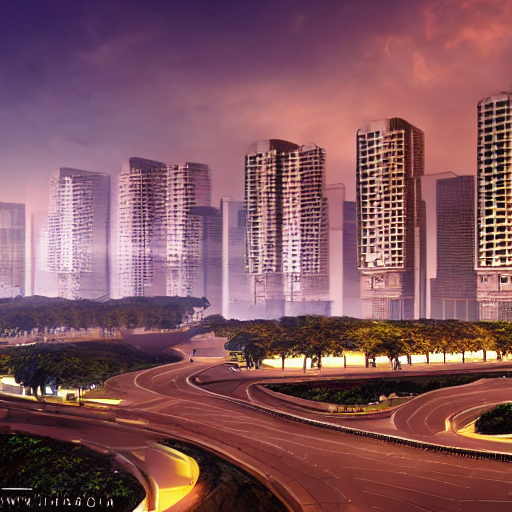

In [3]:
generator = torch.Generator("cuda").manual_seed(12345)

image = pipe(
    prompt="A futuristic Bangalore city at night, cinematic, highly detailed",
    negative_prompt="blurry, distorted, low quality",
    num_inference_steps=30,
    guidance_scale=7.5,
    generator=generator,
).images[0]

image.save("image.png")
image

In [4]:
import time
from IPython.display import display

def generate(prompt, steps=30, guidance=7.5, seed=12345):
    g = torch.Generator("cuda").manual_seed(seed)
    start = time.time()
    img = pipe(
        prompt=prompt,
        negative_prompt="blurry, distorted, low quality",
        num_inference_steps=steps,
        guidance_scale=guidance,
        generator=g,
    ).images[0]
    return img, round(time.time() - start, 1)

prompt = "A robot cooking in a kitchen, digital art"

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Run 1: 5.4s | Run 2: 5.3s


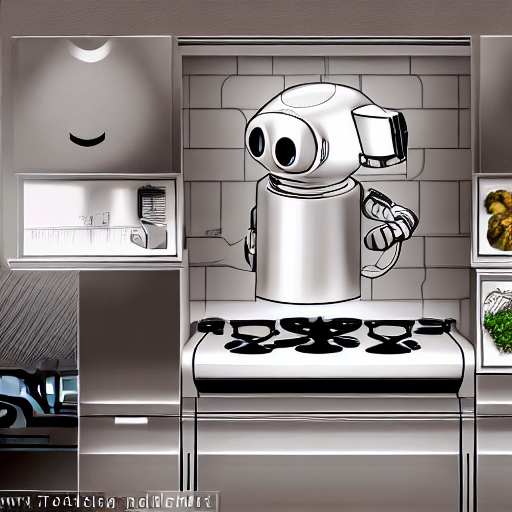

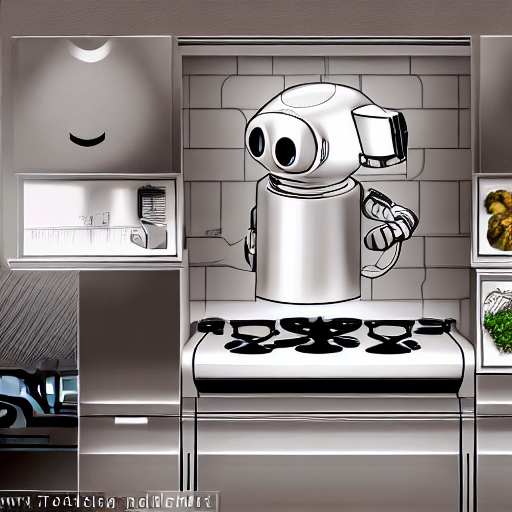

In [5]:
img1, t1 = generate(prompt, seed=12345)
img2, t2 = generate(prompt, seed=12345)
print(f"Run 1: {t1}s | Run 2: {t2}s")
display(img1, img2)

  0%|          | 0/30 [00:00<?, ?it/s]

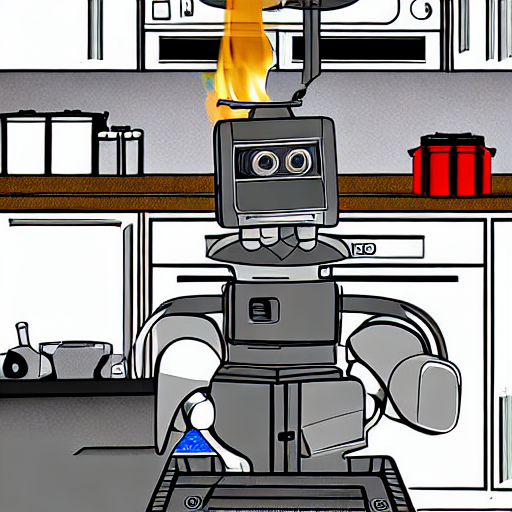

In [6]:
img3, t3 = generate(prompt, seed=999)
display(img3)


  0%|          | 0/10 [00:00<?, ?it/s]

Steps 10: 2.2s


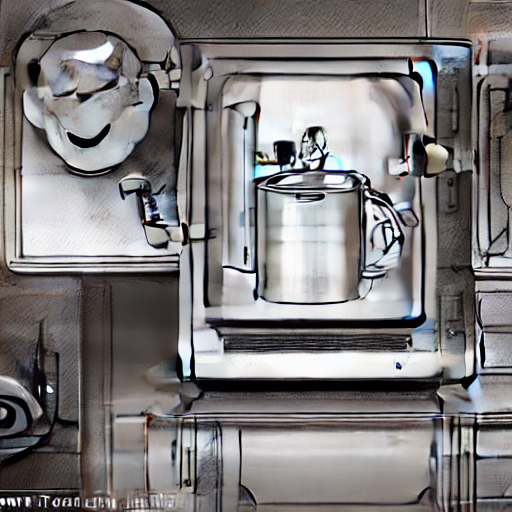

  0%|          | 0/20 [00:00<?, ?it/s]

Steps 20: 3.9s


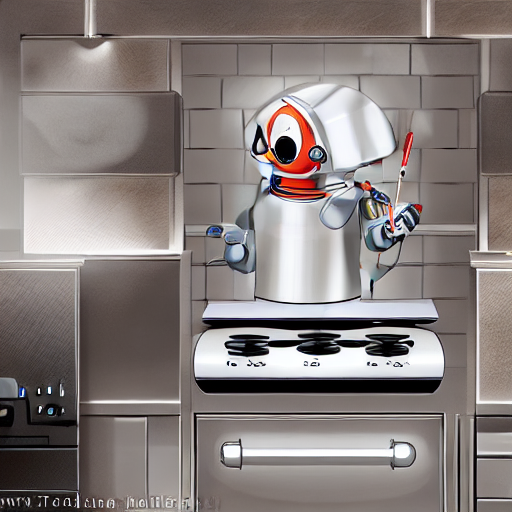

  0%|          | 0/30 [00:00<?, ?it/s]

Steps 30: 5.8s


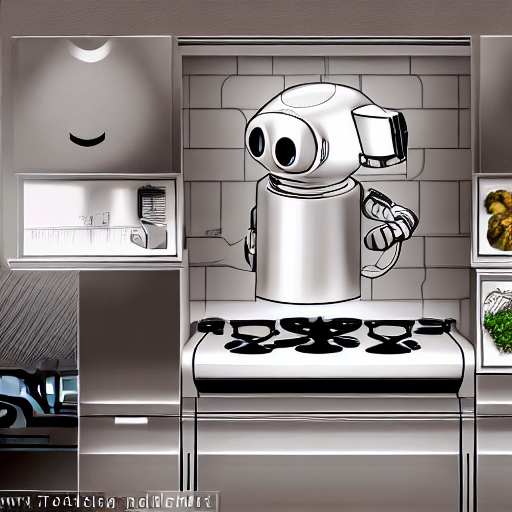

  0%|          | 0/40 [00:00<?, ?it/s]

Steps 40: 7.7s


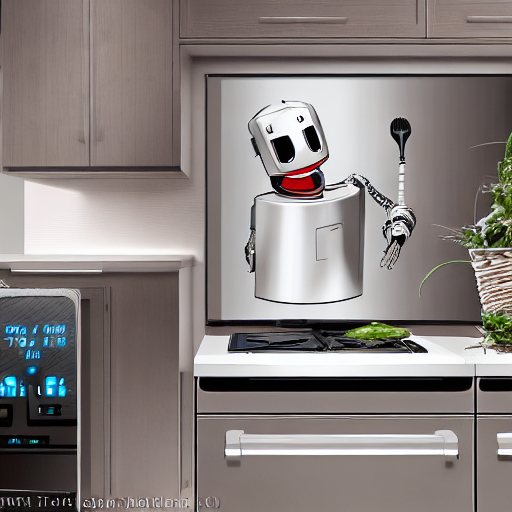

In [7]:
for s in [10, 20, 30, 40]:
    img, t = generate(prompt, steps=s)
    print(f"Steps {s}: {t}s")
    display(img)

  0%|          | 0/30 [00:00<?, ?it/s]

Guidance 5: 5.4s


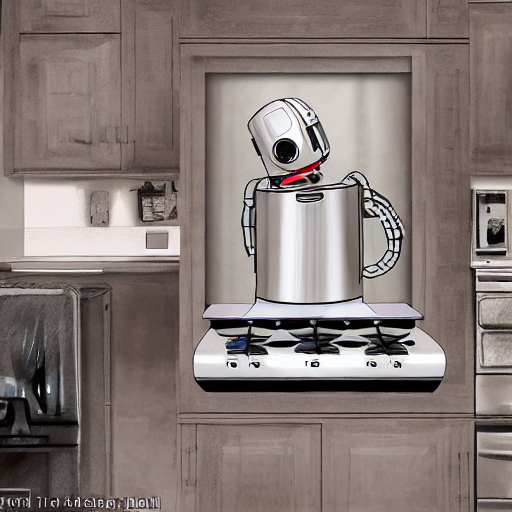

  0%|          | 0/30 [00:00<?, ?it/s]

Guidance 7.5: 5.3s


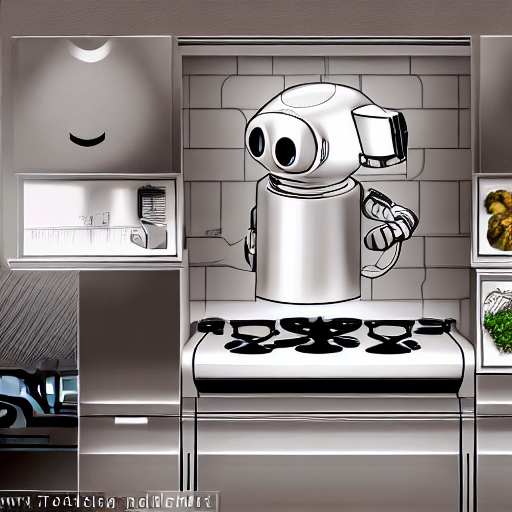

  0%|          | 0/30 [00:00<?, ?it/s]

Guidance 10: 5.3s


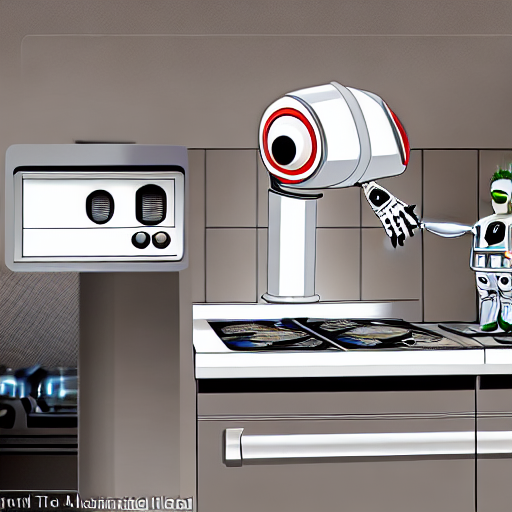

  0%|          | 0/30 [00:00<?, ?it/s]

Guidance 12: 5.3s


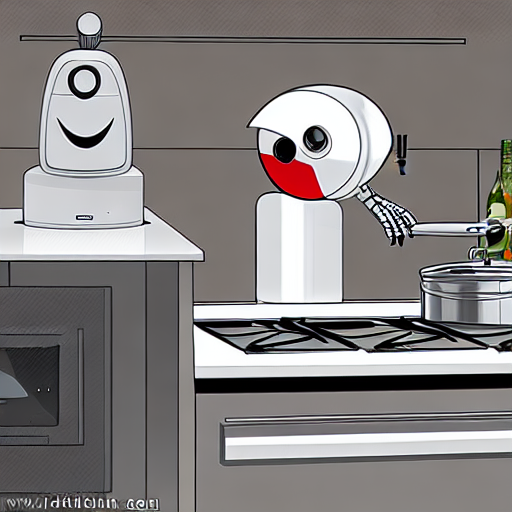

In [8]:
for gs in [5, 7.5, 10, 12]:
    img, t = generate(prompt, guidance=gs)
    print(f"Guidance {gs}: {t}s")
    display(img)